In [27]:
import pandas as pd
df = pd.read_csv("../data/climate_nasa.csv")
df.head()

,date,likesCount,profileName,commentsCount,text
0,2022-09-07T17:12:32.000Z,2,4dca617d86b3fdce80ba7e81fb16e048c9cd9798cdfd6d...,NaN,Neat comparison I have not heard it before.\n ...
1,2022-09-08T14:51:13.000Z,0,518ab97f2d115ba5b6f03b2fba2ef2b120540c9681288b...,NaN,An excellent way to visualise the invisible! T...
2,2022-09-07T17:19:41.000Z,1,d82e8e24eb633fd625b0aef9b3cb625cfb044ceb8483e1...,3.0,Does the CO2/ghg in the troposphere affect the...
3,2022-09-08T00:51:30.000Z,4,37a509fa0b5177a2233c7e2d0e2b2d6916695fa9fba3f2...,NaN,excellent post! I defo feel the difference - o...
4,2022-09-07T19:06:20.000Z,16,e54fbbd42a729af9d04d9a5cc1f9bbfe8081a31c219ecb...,26.0,"Yes, and carbon dioxide does not harm the Eart..."


In [20]:
df.info()
df.describe()
df.columns

<class 'pandas.DataFrame'>
RangeIndex: 522 entries, 0 to 521
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           522 non-null    str    
 1   likesCount     522 non-null    int64  
 2   profileName    522 non-null    str    
 3   commentsCount  244 non-null    float64
 4   text           504 non-null    str    
dtypes: float64(1), int64(1), str(3)
memory usage: 20.5 KB


Index(['date', 'likesCount', 'profileName', 'commentsCount', 'text'], dtype='str')

In [21]:
df.isnull().sum()

date               0
likesCount         0
profileName        0
commentsCount    278
text              18
dtype: int64

In [23]:
df.tail()

,date,likesCount,profileName,commentsCount,text
517,2022-12-22T17:21:37.000Z,0,9e17b1a6422032d47472f0216c73aafda7587e302eed5e...,NaN,One can only hope for a peak 😞
518,2022-12-22T17:19:51.000Z,1,48e55d898603a136aefc44771f248bffd67242583a462a...,5.0,what is the error margin for the temperature e...
519,2022-12-22T17:12:57.000Z,3,ca5d2611814cf8c9844ed06d9916d876d2dba94dac5ff2...,NaN,We all should volenteerly help in reducing Glo...
520,2022-12-22T17:01:12.000Z,1,a87c8aea74c9b97002b368d6143ce9c2809dcaec3103fb...,NaN,Sergio Yepes
521,2022-12-22T17:00:08.000Z,12,cc70f6c9dcc2637b1c5fd90046834612627c752b828cb4...,1.0,"We're experiencing severe, abnormal weather pa..."


In [32]:
print(df.columns)

Index(['date', 'likesCount', 'profileName', 'commentsCount', 'text'], dtype='str')


In [ ]:
import re

def clean_text(text):
    text = str(text)
    text = text.lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^a-z\s]", "", text)
    return text

df['clean_text'] = df['text'].apply(clean_text)

In [39]:
df['text'] = df['text'].fillna("")

In [40]:
df['clean_text'] = df['text'].apply(clean_text)

In [41]:
df[['text', 'clean_text']].head()

,text,clean_text
0,Neat comparison I have not heard it before.\n ...,neat comparison i have not heard it before\n i...
1,An excellent way to visualise the invisible! T...,an excellent way to visualise the invisible th...
2,Does the CO2/ghg in the troposphere affect the...,does the coghg in the troposphere affect the s...
3,excellent post! I defo feel the difference - o...,excellent post i defo feel the difference one...
4,"Yes, and carbon dioxide does not harm the Eart...",yes and carbon dioxide does not harm the earth...


In [46]:
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

def remove_stopwords(text):
    return " ".join([word for word in text.split() if word not in stop_words])

df['clean_text'] = df['clean_text'].apply(remove_stopwords)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [47]:
from nltk.stem import PorterStemmer

stemmer = PorterStemmer()

def stemming(text):
    return " ".join([stemmer.stem(word) for word in text.split()])

df['clean_text'] = df['clean_text'].apply(stemming)

In [48]:
print("Original:", df['text'][0])
print("Processed:", df['clean_text'][0])

Original: Neat comparison I have not heard it before.
 I would say that CO2 is like a disco ball so energy and collide with countless molecules as it bounces around in our atmosphere.
Processed: neat comparison heard would say co like disco ball energi collid countless molecul bounc around atmospher


In [49]:
df.to_csv("../data/cleaned_climate_nasa.csv", index=False)

In [50]:
from textblob import TextBlob

In [51]:
def get_sentiment(text):
    return TextBlob(text).sentiment.polarity

In [52]:
df['sentiment_score'] = df['clean_text'].apply(get_sentiment)

In [53]:
def label_sentiment(score):
    if score > 0:
        return "Positive"
    elif score < 0:
        return "Negative"
    else:
        return "Neutral"

df['sentiment'] = df['sentiment_score'].apply(label_sentiment)

In [54]:
df[['clean_text', 'sentiment_score', 'sentiment']].head()

,clean_text,sentiment_score,sentiment
0,neat comparison heard would say co like disco ...,0.000000,Neutral
1,excel way visualis invis thank,0.000000,Neutral
2,coghg tropospher affect stratospher warmer tro...,0.000000,Neutral
3,excel post defo feel differ one drink make fee...,-0.714286,Negative
4,ye carbon dioxid harm earth like peopl make fa...,-0.375000,Negative


In [55]:
df['sentiment'].value_counts()

sentiment
Neutral     266
Positive    174
Negative     82
Name: count, dtype: int64

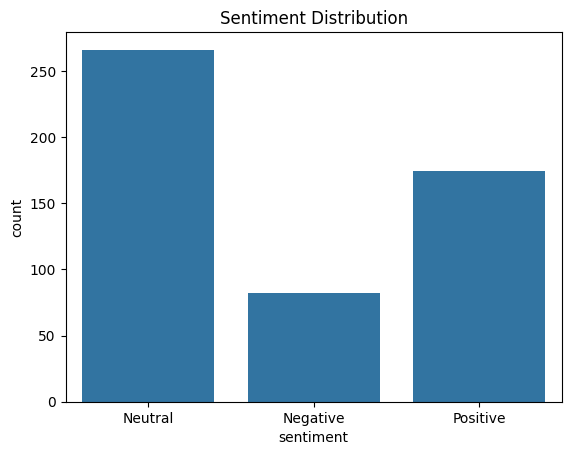

In [56]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='sentiment', data=df)
plt.title("Sentiment Distribution")
plt.show()

In [58]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

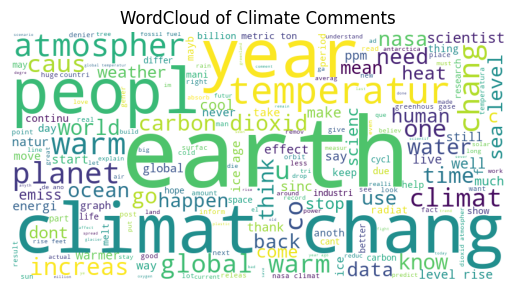

In [59]:
text = " ".join(df['clean_text'])

wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)

plt.imshow(wordcloud)
plt.axis("off")
plt.title("WordCloud of Climate Comments")
plt.show()

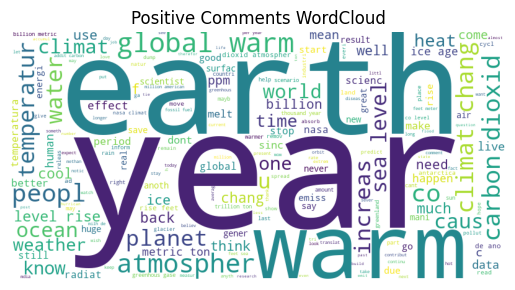

In [60]:
positive_text = " ".join(df[df['sentiment'] == 'Positive']['clean_text'])

wc_pos = WordCloud(width=800, height=400, background_color='white').generate(positive_text)

plt.imshow(wc_pos)
plt.axis("off")
plt.title("Positive Comments WordCloud")
plt.show()

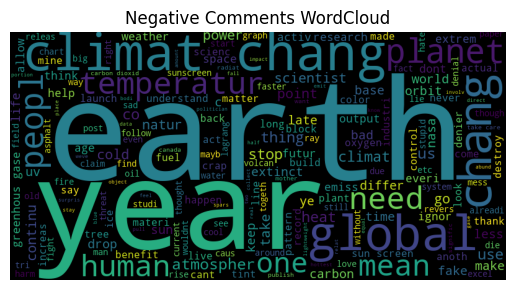

In [61]:
negative_text = " ".join(df[df['sentiment'] == 'Negative']['clean_text'])

wc_neg = WordCloud(width=800, height=400, background_color='black').generate(negative_text)

plt.imshow(wc_neg)
plt.axis("off")
plt.title("Negative Comments WordCloud")
plt.show()

In [62]:
df.groupby('sentiment')['likesCount'].mean()

sentiment
Negative    4.402439
Neutral     3.120301
Positive    7.316092
Name: likesCount, dtype: float64

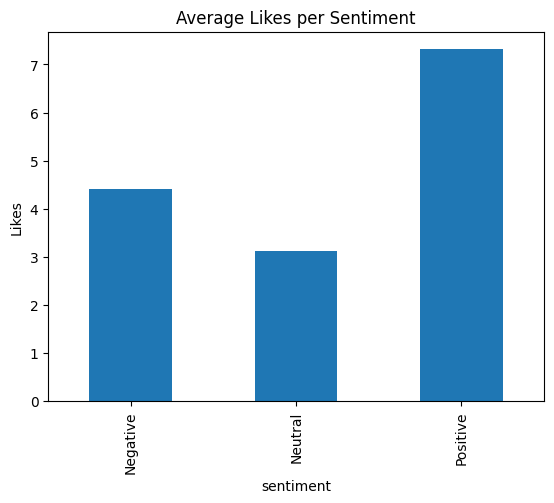

In [63]:
df.groupby('sentiment')['likesCount'].mean().plot(kind='bar')
plt.title("Average Likes per Sentiment")
plt.ylabel("Likes")
plt.show()

In [64]:
plt.savefig("../outputs/graphs/sentiment_plot.png")

<Figure size 640x480 with 0 Axes>

In [65]:
plt.savefig("../outputs/graphs/wordcloud.png")

<Figure size 640x480 with 0 Axes>

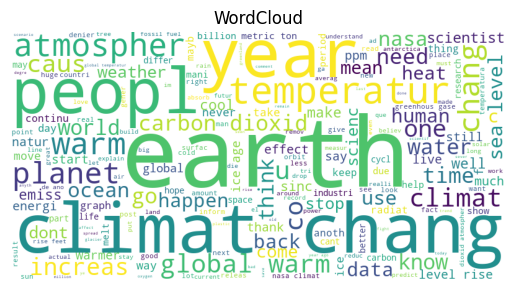

In [ ]:
plt.imshow(wordcloud)
plt.axis("off")
plt.title("WordCloud")

plt.savefig("../outputs/graphs/wordcloud.png")
plt.show()

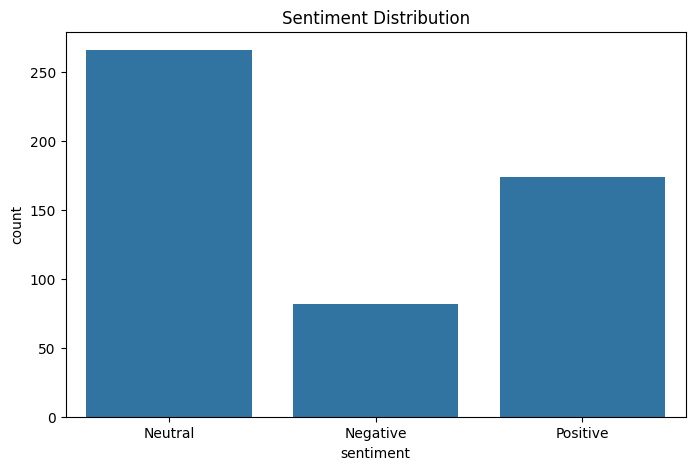

In [71]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5)) 

sns.countplot(x='sentiment', data=df)

plt.title("Sentiment Distribution")

plt.savefig("../outputs/graphs/sentiment_plot.png") 
plt.show() 